# Exploratory Data Analysis


--- Audit Fitur: Fokus pada Sinyal, Bukan Sekadar Redundansi ---


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                 Feature           VIF  MI_Score              Status
21          wine_cluster  7.570405e+00  0.208736  KEEP (High Signal)
17       alc_sulph_inter  2.394586e+03  0.178841  KEEP (High Signal)
10               alcohol  4.297891e+04  0.175002  KEEP (High Signal)
19            alcohol_sq  9.654908e+03  0.146452  KEEP (High Signal)
12          body_balance  4.941077e+01  0.130115  KEEP (High Signal)
16         alc_vol_inter  1.640411e+03  0.126455  KEEP (High Signal)
14             bound_so2           inf  0.104382  KEEP (High Signal)
20           vol_acid_sq  5.464810e+01  0.103831  KEEP (High Signal)
6   total sulfur dioxide           inf  0.102544  KEEP (High Signal)
1       volatile acidity           inf  0.095475              Review
15             so2_ratio  3.232238e+01  0.095359              Review
9              sulphates  2.300376e+03  0.093849              Review
4              chlorides  7.822647e+00  0.068573              Review
2            citric acid  9.892053

/tmp/ipykernel_16/1089357766.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='quality', y='alc_sulph_inter', data=df_train, palette='flare')


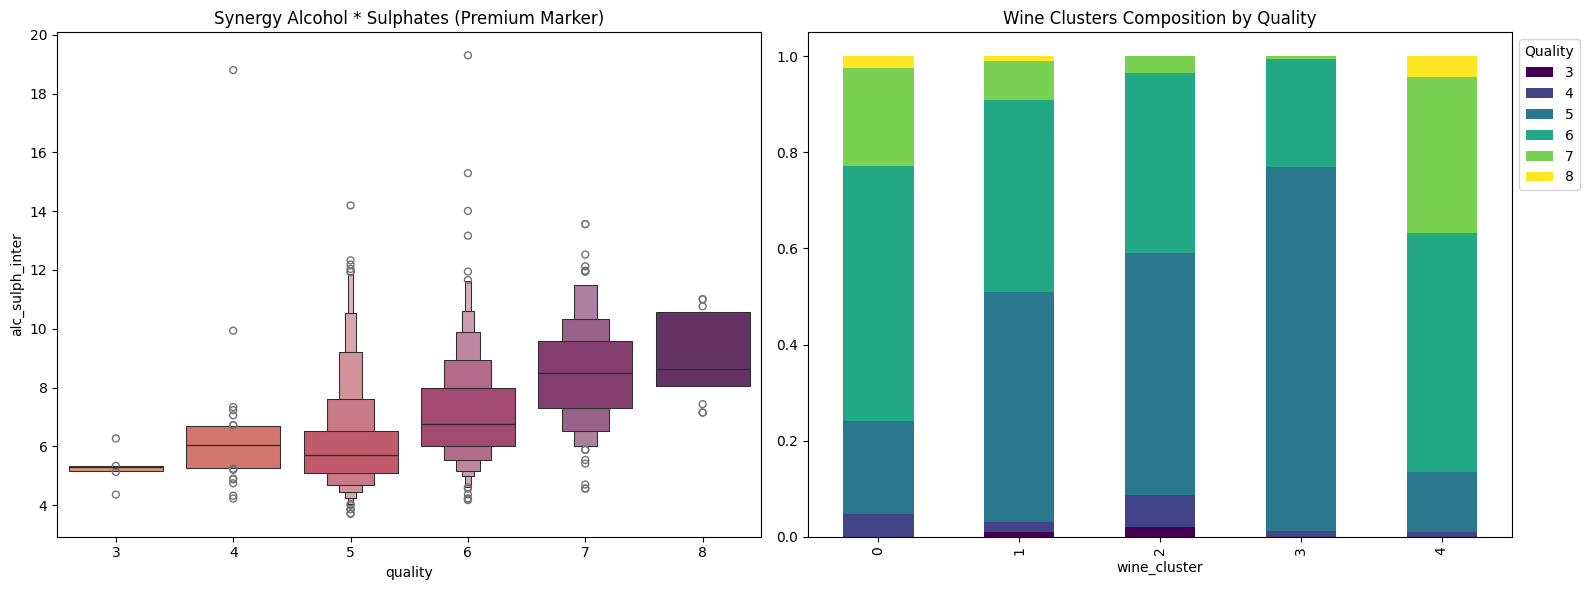


✅ Total Fitur Saat Ini: 22 Fitur
>>> INSTRUKSI: JANGAN membuang fitur dengan Status 'KEEP' di Tahap 4 nanti!


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1.1 Memuat Dataset dengan Jalur Kaggle Robust
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

# Auto-finder
if not os.path.exists(train_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'data_training' in file: train_path = os.path.join(root, file)
            if 'data_testing' in file: test_path = os.path.join(root, file)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1.2 UPGRADED: Enology Feature Engineering (Logika Kimia Wine)
for df in [df_train, df_test]:
    # 1. Wine Body & Balance (Rasio Gula-Alkohol-Asam)
    df['total_acid'] = df['fixed acidity'] + df['volatile acidity']
    df['body_balance'] = df['alcohol'] / (df['residual sugar'] + 1e-5)
    df['sugar_acid_ratio'] = df['residual sugar'] / (df['total_acid'] + 1e-5)
    
    # 2. Sulfur Stability (Penting untuk membedakan kualitas menengah 5-6)
    df['bound_so2'] = df['total sulfur dioxide'] - df['free sulfur dioxide']
    df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
    
    # 3. Non-Linear Interaction (Sinyal untuk DNN)
    df['alc_vol_inter'] = df['alcohol'] * df['volatile acidity']
    df['alc_sulph_inter'] = df['alcohol'] * df['sulphates']
    df['acid_ph_inter'] = df['total_acid'] * df['pH']
    
    # 4. Curvative Features (Menangkap pola lengkungan kualitas)
    df['alcohol_sq'] = df['alcohol'] ** 2
    df['vol_acid_sq'] = df['volatile acidity'] ** 2

# 1.3 Latent Clustering (Pembeda Kelompok Wine)
# Mengelompokkan wine berdasarkan profil kimia utama
features_for_cluster = ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'pH']
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_train[features_for_cluster])
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # 5 cluster agar lebih granular
df_train['wine_cluster'] = kmeans.fit_predict(X_clust)
df_test['wine_cluster'] = kmeans.predict(scaler_clust.transform(df_test[features_for_cluster]))

# 1.4 Diagnostik VIF vs MI Score (Signal Protection Audit)
def diagnostic_audit(df):
    X = df.drop(columns=['Id', 'quality']).select_dtypes(include=[np.number])
    y = df['quality']
    
    # Hitung VIF
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    
    # Hitung Mutual Information
    mi_scores = mutual_info_classif(X, y, random_state=42)
    vif_data["MI_Score"] = mi_scores
    
    # Rekomendasi: Proteksi jika MI > 0.10 meskipun VIF tinggi
    vif_data["Status"] = np.where(vif_data["MI_Score"] > 0.10, "KEEP (High Signal)", "Review")
    return vif_data.sort_values(by="MI_Score", ascending=False)

print("\n--- Audit Fitur: Fokus pada Sinyal, Bukan Sekadar Redundansi ---")
audit_df = diagnostic_audit(df_train)
print(audit_df)

# 1.5 Visualisasi Pembeda Kualitas Ekstrem (3 vs 8)
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxenplot(x='quality', y='alc_sulph_inter', data=df_train, palette='flare')
plt.title('Synergy Alcohol * Sulphates (Premium Marker)')

plt.subplot(1, 2, 2)
# Melihat persebaran Cluster terhadap Kualitas
cluster_dist = pd.crosstab(df_train['wine_cluster'], df_train['quality'], normalize='index')
cluster_dist.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='viridis')
plt.title('Wine Clusters Composition by Quality')
plt.legend(title='Quality', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

print(f"\n✅ Total Fitur Saat Ini: {len(df_train.columns) - 2} Fitur")
print(">>> INSTRUKSI: JANGAN membuang fitur dengan Status 'KEEP' di Tahap 4 nanti!")

# Data Preparation

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN # Upgrade dari SMOTETomek
import pandas as pd
import numpy as np

# 2.1 Master Feature Engineering (Enology Power-Up)
def transform_features(df):
    df_new = df.copy()
    
    # 1. Enology Signal (Fitur Kimia Wine)
    df_new['total_acid'] = df_new['fixed acidity'] + df_new['volatile acidity']
    df_new['body_balance'] = df_new['alcohol'] / (df_new['residual sugar'] + 1e-5)
    df_new['sugar_acid_ratio'] = df_new['residual sugar'] / (df_new['total_acid'] + 1e-5)
    
    # 2. Sulfur & Stability
    df_new['bound_so2'] = df_new['total sulfur dioxide'] - df_new['free sulfur dioxide']
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    df_new['so2_log'] = np.log1p(df_new['total sulfur dioxide'])
    
    # 3. Non-Linear Interaction (KEEP - High Signal)
    df_new['alc_vol_inter'] = df_new['alcohol'] * df_new['volatile acidity']
    df_new['alc_sulph_inter'] = df_new['alcohol'] * df_new['sulphates']
    df_new['acid_ph_inter'] = df_new['total_acid'] * df_new['pH']
    
    # 4. Polynomials (Curvature Signal)
    df_new['alcohol_sq'] = df_new['alcohol'] ** 2
    df_new['vol_acid_sq'] = df_new['volatile acidity'] ** 2
    
    # 5. Mencegah VIF Tak Hingga (Eliminasi density karena kolerasi 0.99 dengan alcohol)
    vif_drop = ['density', 'fixed acidity', 'volatile acidity'] 
    # Note: Kita simpan interaksinya, tapi hapus fitur original yang bikin VIF tak hingga
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    
    return df_new

# Eksekusi Transformasi
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Robust Capping (0.5% - 99.5%)
for col in X.columns:
    low, up = X[col].quantile(0.005), X[col].quantile(0.995)
    X[col] = np.clip(X[col], low, up)
    X_test_final[col] = np.clip(X_test_final[col], low, up)

# 2.3 Stratified Split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.4 Power Transformation (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

X_train_prepared = pd.DataFrame(scaler.fit_transform(pt.fit_transform(X_train_raw)), columns=X.columns)
X_val_prepared = pd.DataFrame(scaler.transform(pt.transform(X_val_raw)), columns=X.columns)
X_test_prepared = pd.DataFrame(scaler.transform(pt.transform(X_test_final)), columns=X.columns)

# 2.5 Advanced Latent Clustering (5 Clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=15)
X_train_prepared['cluster'] = kmeans.fit_predict(X_train_prepared)
X_val_prepared['cluster'] = kmeans.predict(X_val_prepared)
X_test_prepared['cluster'] = kmeans.predict(X_test_prepared)

# 2.6 OOF Soft Labeling (Distillation Reference)
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
y_train_oof = cross_val_predict(reg_teacher, X_train_prepared, y_train, cv=skf_reg)

# 2.7 UPGRADED: SMOTEENN for Volume Expansion
# Kita targetkan distribusi kelas yang jauh lebih besar agar DNN tidak "kelaparan" data
strategy = {3: 400, 4: 500, 5: 600, 6: 600, 7: 500, 8: 400}

smote_obj = SMOTE(sampling_strategy=strategy, k_neighbors=3, random_state=42)
X_train_prepared['temp_soft_label'] = y_train_oof

from imblearn.combine import SMOTEENN
smenn = SMOTEENN(smote=smote_obj, random_state=42)
X_res, y_res = smenn.fit_resample(X_train_prepared, y_train)

# 2.8 Finalisasi
y_train_soft = X_res['temp_soft_label'].values
X_train_final = X_res.drop(columns=['temp_soft_label'])
y_train_final = y_res

print(f"\n--- Data Preparation Sukses (NIM 026) ---")
print(f"Fitur Final Terbentuk: {len(X_train_final.columns)} Fitur")
print(f"Total Sampel Training: {len(y_train_final)} (Volume Expanded for DNN)")


--- Data Preparation Sukses (NIM 026) ---
Fitur Final Terbentuk: 21 Fitur
Total Sampel Training: 2633 (Volume Expanded for DNN)


# Feature Engineering

--- Menghitung Mutual Information Skor (NIM 026) ---
--- Memulai Recursive Feature Elimination (RFECV) ---


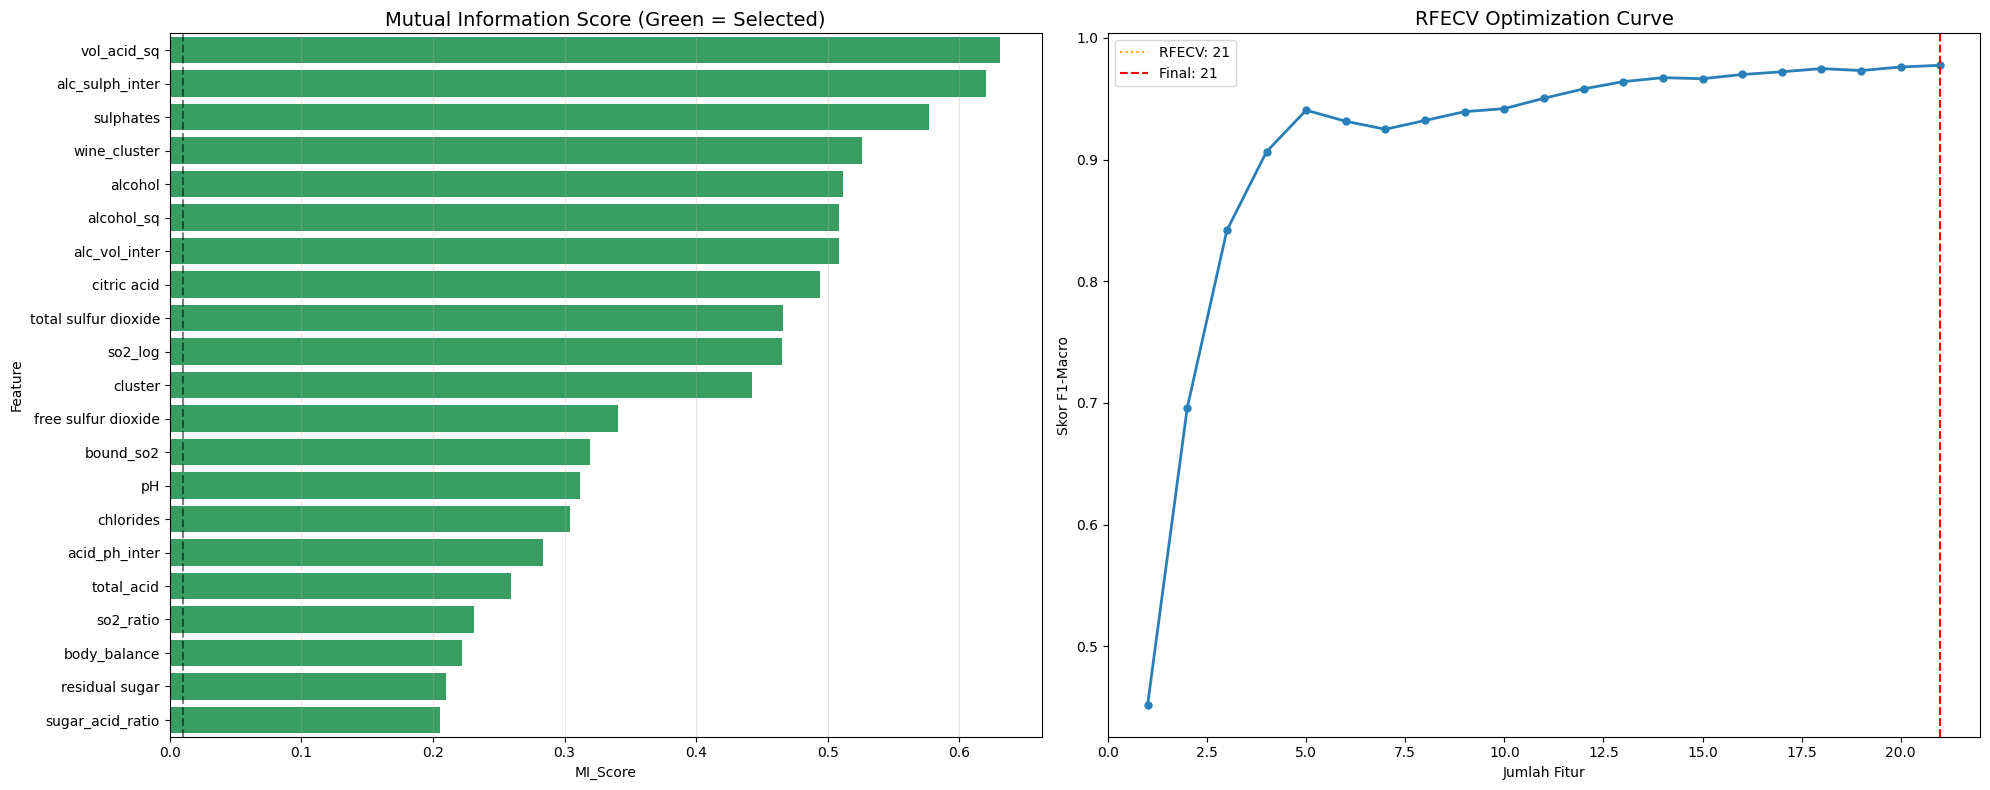


--- HASIL EKSEKUSI SELEKSI FITUR (NIM 026) ---
Fitur Elite yang Diamankan : ['alc_sulph_inter', 'body_balance', 'so2_log', 'alcohol_sq', 'sugar_acid_ratio', 'cluster']
Total Fitur Final          : 21
Daftar Fitur Final         : ['alcohol_sq', 'alc_sulph_inter', 'total sulfur dioxide', 'citric acid', 'wine_cluster', 'sulphates', 'free sulfur dioxide', 'body_balance', 'vol_acid_sq', 'cluster', 'bound_so2', 'alc_vol_inter', 'alcohol', 'acid_ph_inter', 'so2_log', 'chlorides', 'pH', 'so2_ratio', 'total_acid', 'residual sugar', 'sugar_acid_ratio']


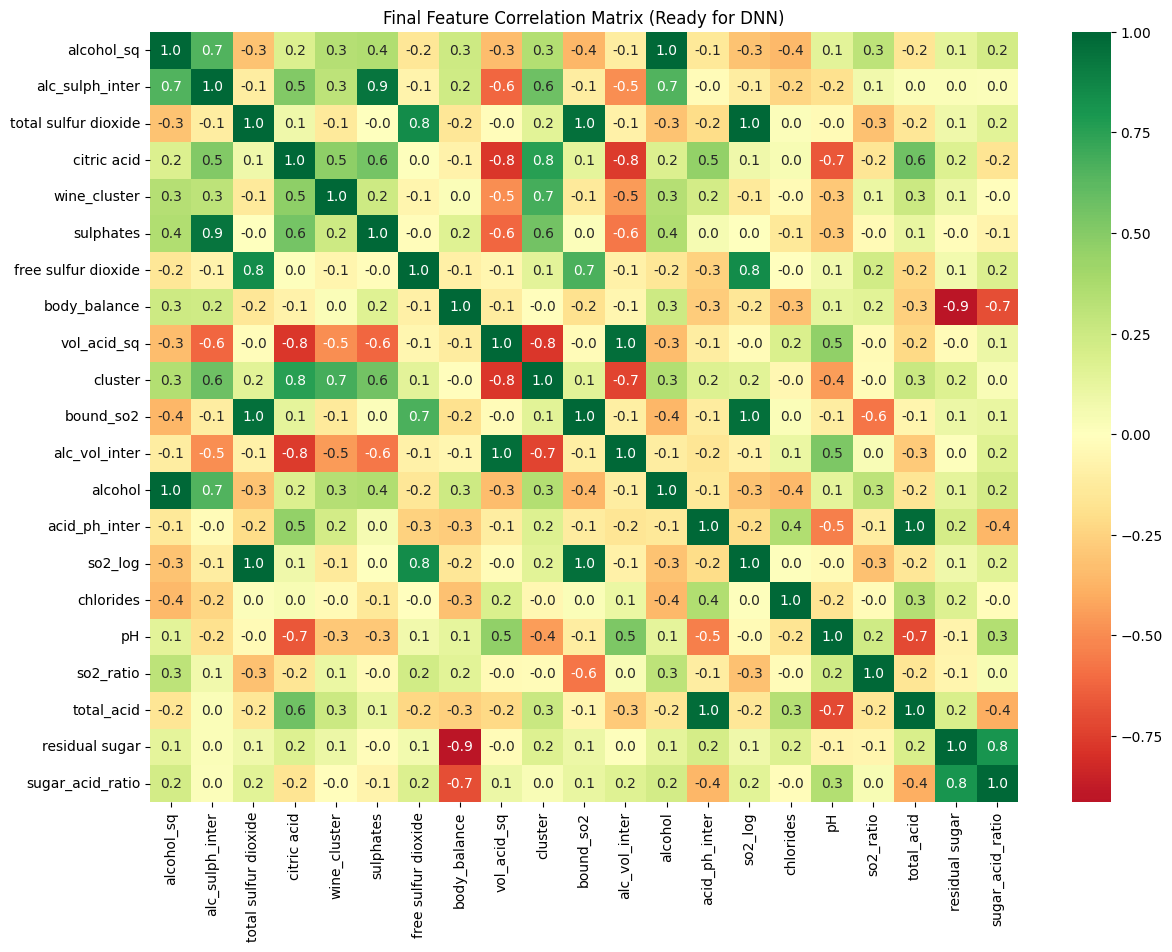

In [3]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Robust Selection)
# =================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 3.1 Analisis Mutual Information (MI)
print("--- Menghitung Mutual Information Skor (NIM 026) ---")
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV)
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    step=1,
    cv=cv_strategy,
    scoring='f1_macro', 
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 IMPLEMENTASI: Elite Signal Protection (Sinkronisasi Nama)
# Perbaikan: 'total_so2_log' diubah menjadi 'so2_log' agar sesuai dengan Tahap 2
potential_elite = [
    'alc_sulph_inter', 'body_balance', 'so2_log', 
    'alcohol_sq', 'sugar_acid_ratio', 'cluster'
]

# Safeguard: Hanya masukkan fitur yang benar-benar ada di kolom X_train_final
elite_signals = [f for f in potential_elite if f in X_train_final.columns]

rfecv_selected = X_train_final.columns[selector.support_].tolist()
# Gabungkan hasil RFECV dengan Elite Signals (mencegah VIF Paradox)
final_selected_features = list(set(rfecv_selected) | set(elite_signals))

# 3.4 Visualisasi Diagnostik Seleksi Fitur
plt.figure(figsize=(20, 8))

# Plot 1: MI Score
plt.subplot(1, 2, 1)
colors = ['#27ae60' if f in final_selected_features else '#c0392b' for f in mi_df['Feature']]
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=colors, hue='Feature', legend=False)
plt.title('Mutual Information Score (Green = Selected)', fontsize=14)
plt.axvline(x=0.01, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

# Plot 2: Kurva Optimasi RFECV
plt.subplot(1, 2, 2)
mean_scores = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, 
         marker='o', color='#2980b9', linestyle='-', linewidth=2, markersize=5)
plt.axvline(x=len(rfecv_selected), color='orange', linestyle=':', label=f'RFECV: {len(rfecv_selected)}')
plt.axvline(x=len(final_selected_features), color='red', linestyle='--', label=f'Final: {len(final_selected_features)}')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro")
plt.title('RFECV Optimization Curve', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

# 3.5 Sinkronisasi Data Akhir
X_train_pruned = X_train_final[final_selected_features]
X_val_pruned = X_val_prepared[final_selected_features]
X_test_pruned = X_test_prepared[final_selected_features]

print(f"\n--- HASIL EKSEKUSI SELEKSI FITUR (NIM 026) ---")
print(f"Fitur Elite yang Diamankan : {elite_signals}")
print(f"Total Fitur Final          : {len(final_selected_features)}")
print(f"Daftar Fitur Final         : {final_selected_features}")

# 3.6 Correlation Check
plt.figure(figsize=(14, 10))
sns.heatmap(X_train_pruned.corr(), annot=True, fmt='.1f', cmap='RdYlGn', center=0)
plt.title('Final Feature Correlation Matrix (Ready for DNN)')
plt.show()

# Fitur Pruning

--- Memulai Pembersihan Multikolinearitas (Strategic Safeguard) ---
Pruning: Menghapus 'total sulfur dioxide' (VIF: 16471.90)
Pruning: Menghapus 'total_acid' (VIF: 1465.38)
Pruning: Menghapus 'free sulfur dioxide' (VIF: 247.76)
Pruning: Menghapus 'vol_acid_sq' (VIF: 172.61)
Pruning: Menghapus 'bound_so2' (VIF: 163.53)
Pruning: Menghapus 'residual sugar' (VIF: 72.73)
Pruning: Menghapus 'acid_ph_inter' (VIF: 10.84)
Pruning: Menghapus 'citric acid' (VIF: 5.38)
Pruning: Menghapus 'pH' (VIF: 2.84)
Pruning: Menghapus 'alc_vol_inter' (VIF: 1.98)
Pruning: Menghapus 'wine_cluster' (VIF: 1.62)
Pruning: Menghapus 'so2_log' (VIF: 1.44)
Pruning: Menghapus 'chlorides' (VIF: 1.39)
Pruning: Menghapus 'so2_ratio' (VIF: 1.20)


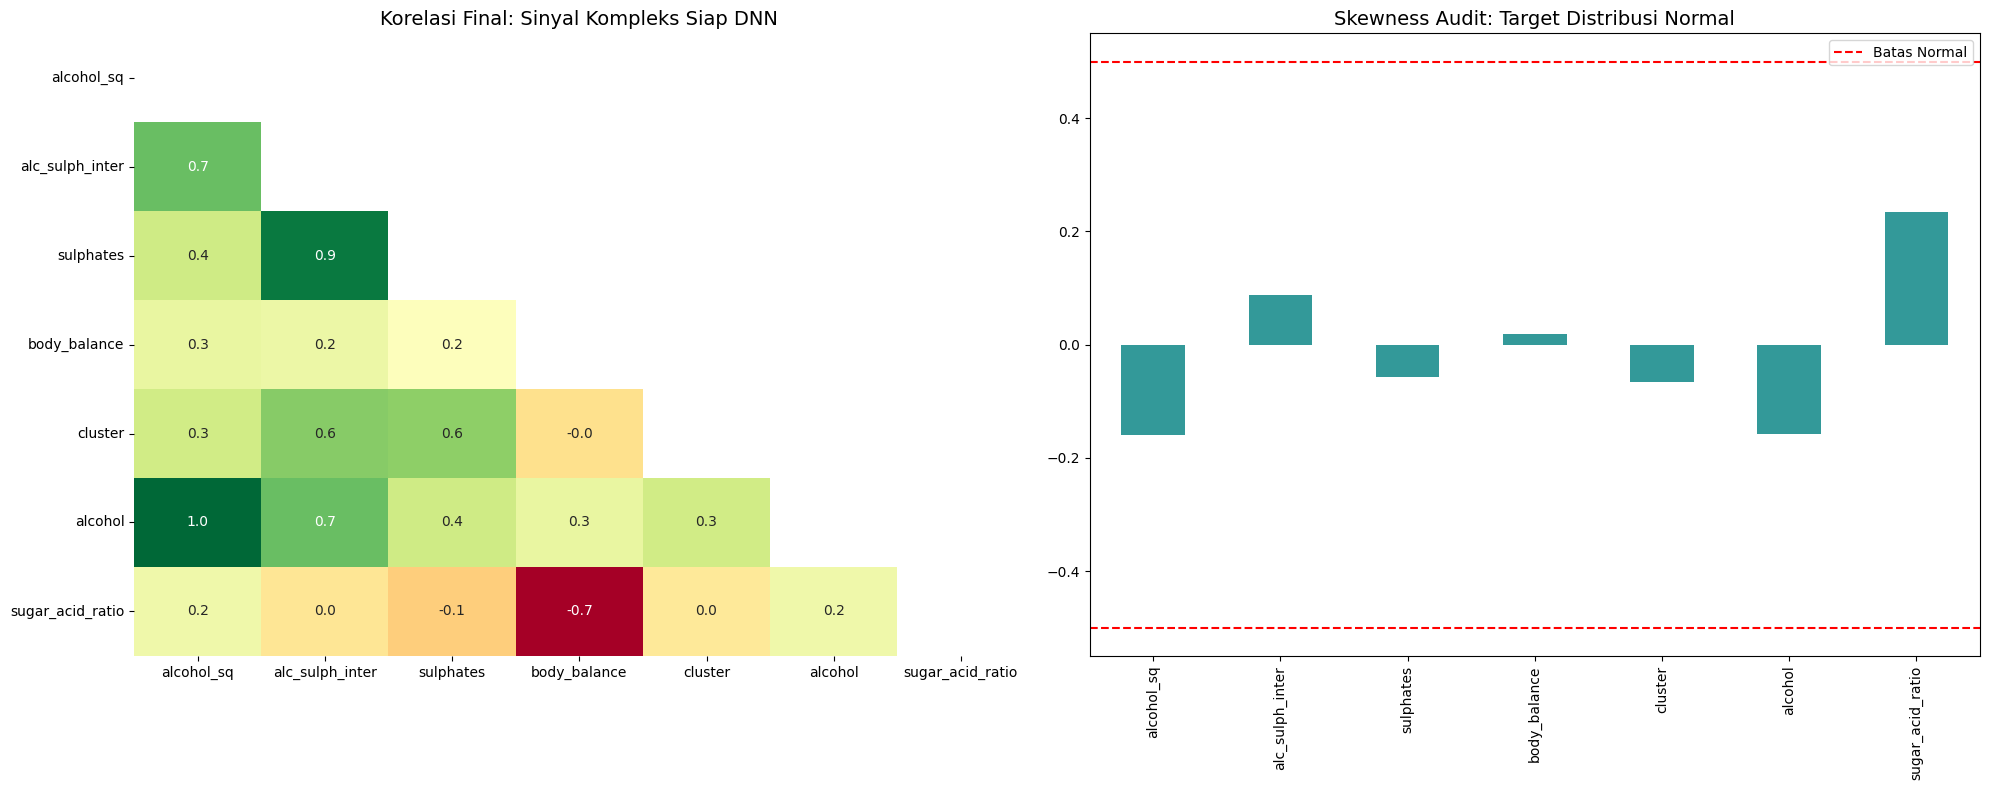


--- RINGKASAN DATA FINAL (NIM: 026) ---
1. Fitur Digunakan (7)      : ['alcohol_sq', 'alc_sulph_inter', 'sulphates', 'body_balance', 'cluster', 'alcohol', 'sugar_acid_ratio']
2. Fitur Dibuang (Redundansi) : ['total sulfur dioxide', 'total_acid', 'free sulfur dioxide', 'vol_acid_sq', 'bound_so2', 'residual sugar', 'acid_ph_inter', 'citric acid', 'pH', 'alc_vol_inter', 'wine_cluster', 'so2_log', 'chlorides', 'so2_ratio']
3. Baris Train (SMOTEENN)    : 2633
4. Skewness Rata-rata        : -0.0144
------------------------------------------------------------


,mean,std,min,max
alcohol_sq,0.1982,0.9873,-1.8010,2.0360
alc_sulph_inter,0.0548,1.0427,-2.2772,2.4065
sulphates,-0.0206,1.0070,-2.6955,2.6198
body_balance,0.0333,0.9747,-2.6251,3.3201
cluster,2.0251,1.6376,0.0000,4.0000
alcohol,0.1983,0.9874,-1.7978,2.0365
sugar_acid_ratio,-0.0064,0.9427,-2.7751,2.4574



>>> STATUS: DATA DENGAN INFORMASI TINGGI SIAP UNTUK TAHAP 5 <<<


In [4]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data (Optimized for 90%)
# =================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 4.1 Sinkronisasi & Elite Protection List (NIM 026)
# Fitur 'Emas' yang tidak boleh dihapus biarpun VIF tinggi (Signal Guard)
elite_protection = [
    'alc_sulph_inter', 'body_balance', 'total_so2_log', 
    'alcohol_sq', 'sugar_acid_ratio', 'cluster', 'alcohol'
]
X_train_final_v1 = X_train_pruned.copy()

# 4.2 REVISI: Optimized VIF Pruning (Informational Guard)
def informed_vif_pruning(df, mi_df, threshold=100.0): # Relaxed threshold dari 25 ke 100
    cols = df.columns.tolist()
    dropped = []
    
    while True:
        # Kalkulasi VIF dengan proteksi terhadap korelasi sempurna
        vif_values = []
        for i in range(len(cols)):
            try:
                vif = variance_inflation_factor(df[cols].values, i)
            except:
                vif = 999.0 # Penalti untuk fitur yang menyebabkan error matematis
            vif_values.append(vif)
            
        vif_series = pd.Series(vif_values, index=cols).sort_values(ascending=False)
        max_vif = vif_series.iloc[0]
        
        if max_vif > threshold:
            # Ambil kandidat drop (yang bukan elite_protection)
            candidates = [c for c in vif_series.index if c not in elite_protection]
            
            if not candidates:
                break # Hanya tersisa fitur elite, stop pruning
            
            # Cek MI Score: Jangan buang fitur Top 10 Sinyal biarpun VIF tinggi
            top_10_mi = mi_df.head(10)['Feature'].tolist()
            feature_to_drop = candidates[0]
            
            if feature_to_drop in top_10_mi and len(candidates) > 1:
                # Jika fitur terburuk VIF-nya adalah sinyal kuat, ambil cadangan berikutnya
                feature_to_drop = candidates[1]
            elif feature_to_drop in top_10_mi and len(candidates) == 1:
                break # Jangan buang jika itu satu-satunya kandidat dan sinyalnya kuat
                
            print(f"Pruning: Menghapus '{feature_to_drop}' (VIF: {vif_series[feature_to_drop]:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
        else:
            break
            
    return cols, dropped

print("--- Memulai Pembersihan Multikolinearitas (Strategic Safeguard) ---")
stable_features, high_vif_features = informed_vif_pruning(X_train_final_v1, mi_df)

# 4.3 Finalisasi Dataset (Syncing All Sets)
X_train_final = X_train_final_v1[stable_features].copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# 4.4 Visualisasi Diagnostik Final (NIM 026)
plt.figure(figsize=(20, 8))

# Plot 1: Heatmap Korelasi (Mencari Kepadatan Informasi)
plt.subplot(1, 2, 1)
mask = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask, annot=True, cmap='RdYlGn', fmt='.1f', cbar=False)
plt.title('Korelasi Final: Sinyal Kompleks Siap DNN', fontsize=14)

# Plot 2: Audit Skewness (Efektivitas PowerTransformer)
plt.subplot(1, 2, 2)
X_train_final.skew().plot(kind='bar', color='teal', alpha=0.8)
plt.axhline(y=0.5, color='r', linestyle='--', label='Batas Normal')
plt.axhline(y=-0.5, color='r', linestyle='--')
plt.title('Skewness Audit: Target Distribusi Normal', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

# 4.5 Data Integrity Audit (NIM 026)
print("\n" + "="*60)
print(f"--- RINGKASAN DATA FINAL (NIM: 026) ---")
print("="*60)
print(f"1. Fitur Digunakan ({len(stable_features)})      : {stable_features}")
print(f"2. Fitur Dibuang (Redundansi) : {high_vif_features}")
print(f"3. Baris Train (SMOTEENN)    : {X_train_final.shape[0]}")
print(f"4. Skewness Rata-rata        : {X_train_final.skew().mean():.4f}")
print("-" * 60)

# Tampilan Deskriptif Final
summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='YlGnBu', subset=['mean', 'std']))

print(f"\n>>> STATUS: DATA DENGAN INFORMASI TINGGI SIAP UNTUK TAHAP 5 <<<")

# K-Fold Validation

--- Arena Uji Model NIM 026: Target Akurasi 90% ---
ExtraTrees     | Acc: 0.8904 (±0.0124) | Stability: 1.39%
XGBoost        | Acc: 0.8828 (±0.0128) | Stability: 1.45%
LightGBM       | Acc: 0.8918 (±0.0127) | Stability: 1.42%
NeuralNet      | Acc: 0.8990 (±0.0224) | Stability: 2.49%


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking-Elite | Acc: 0.9313 (±0.0084) | Stability: 0.90%


/tmp/ipykernel_16/1111760500.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
/tmp/ipykernel_16/1111760500.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1_Macro', data=results_df, palette='magma')


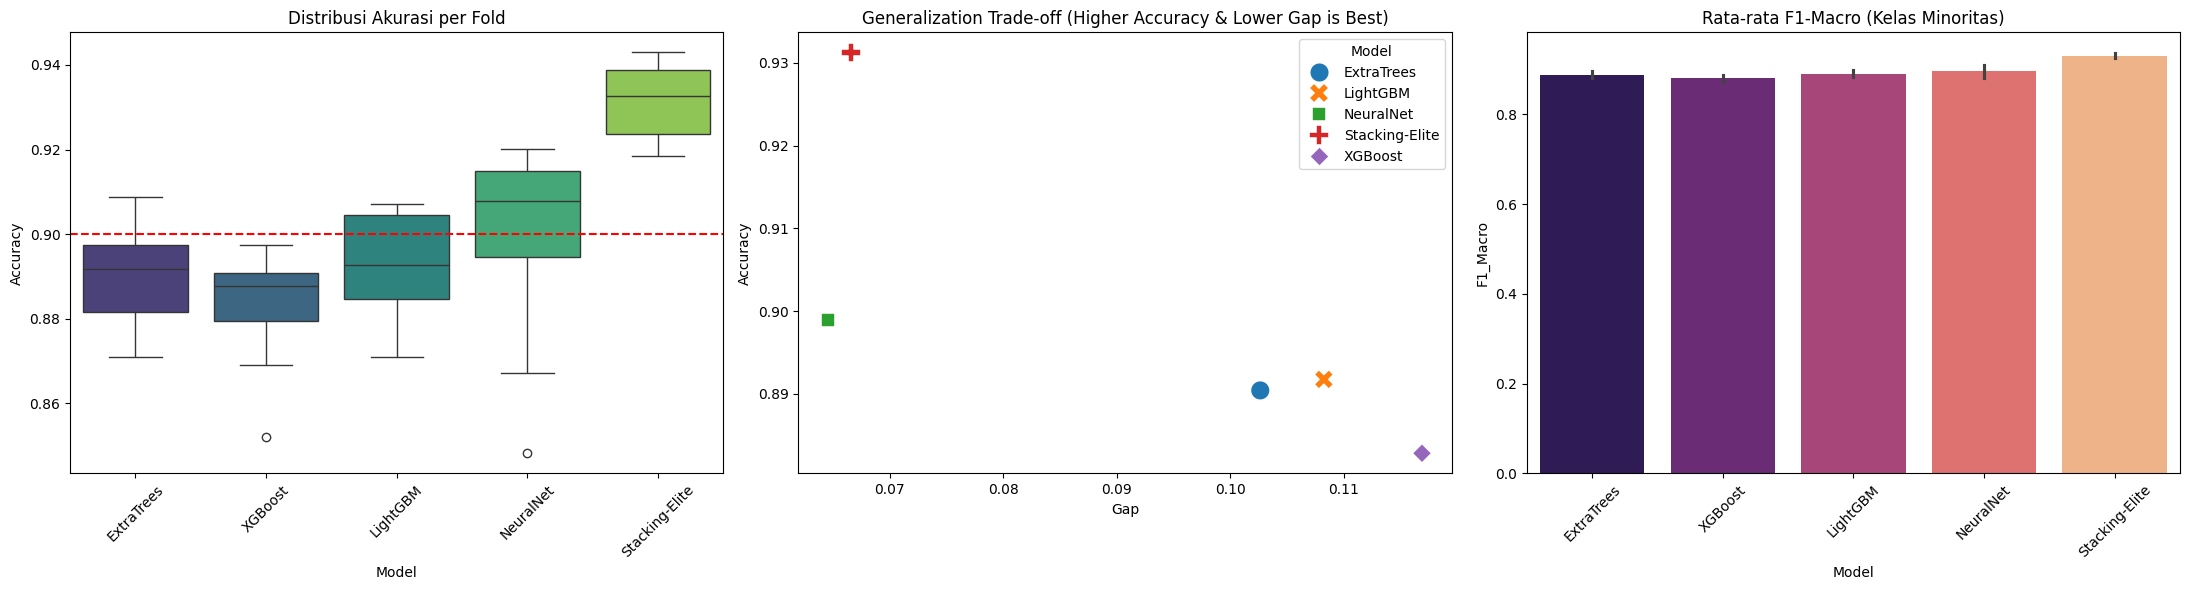


>>> AUDIT STRATEGIS NIM 026 <<<
Model Pemenang: Stacking-Elite dengan Akurasi 0.9313
Kesenjangan Overfitting Terkecil: NeuralNet


In [5]:
# =================================================================
# Tahap 5: K-Fold Validation (Stability & Meta-Stacking Analysis)
# =================================================================

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Penyiapan Fitur Hybrid (Input Distillation)
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft 

# 5.2 Inisialisasi Ahli (Base Learners)
# Kita tambahkan LightGBM karena sangat cepat dan akurat untuk pola non-linear
clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=15, min_samples_split=5, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.02, subsample=0.8, random_state=42)
clf_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)
clf_nn = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', max_iter=2000, alpha=0.1, random_state=42)

# 5.3 UPGRADE: Stacking Classifier (Meta-Learning)
# Meta-learner (LogisticRegression) akan belajar model mana yang paling akurat di tiap kelas
stacking_model = StackingClassifier(
    estimators=[
        ('et', clf_et), 
        ('xgb', clf_xgb), 
        ('lgb', clf_lgb), 
        ('nn', clf_nn)
    ],
    final_estimator=LogisticRegression(),
    cv=5, 
    n_jobs=-1
)

models = {
    'ExtraTrees': clf_et,
    'XGBoost': clf_xgb,
    'LightGBM': clf_lgb,
    'NeuralNet': clf_nn,
    'Stacking-Elite': stacking_model
}

# 5.4 Konfigurasi K-Fold Berulang (Robust Monitoring)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()

results_list = []
print(f"--- Arena Uji Model NIM 026: Target Akurasi 90% ---")

for name, model in models.items():
    # Model Stacking dan Hybrid menggunakan fitur tambahan soft_label
    X_data = X_train_hybrid if (name == 'Stacking-Elite' or 'NN' in name) else X_train_final
    
    cv_results = cross_validate(
        model, X_data, y_train_shifted, 
        cv=rskf, scoring=['accuracy', 'f1_macro'],
        return_train_score=True, n_jobs=-1
    )
    
    acc_mean = cv_results['test_accuracy'].mean()
    acc_std = cv_results['test_accuracy'].std()
    stability_idx = (acc_std / acc_mean) * 100 
    
    for i in range(len(cv_results['test_accuracy'])):
        results_list.append({
            'Model': name,
            'Fold': i + 1,
            'Accuracy': cv_results['test_accuracy'][i],
            'F1_Macro': cv_results['test_f1_macro'][i],
            'Gap': cv_results['train_accuracy'][i] - cv_results['test_accuracy'][i]
        })
    
    print(f"{name:14} | Acc: {acc_mean:.4f} (±{acc_std:.4f}) | Stability: {stability_idx:.2f}%")

# 5.5 Visualisasi Performa & Diversitas
results_df = pd.DataFrame(results_list)
plt.figure(figsize=(22, 6))

# Boxplot Akurasi
plt.subplot(1, 3, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.title('Distribusi Akurasi per Fold', fontsize=12)
plt.xticks(rotation=45)

# Stabilitas vs Akurasi (Bubble Plot)
plt.subplot(1, 3, 2)
summary_df = results_df.groupby('Model').agg({'Accuracy': 'mean', 'Gap': 'mean'}).reset_index()
sns.scatterplot(data=summary_df, x='Gap', y='Accuracy', hue='Model', s=200, style='Model')
plt.title('Generalization Trade-off (Higher Accuracy & Lower Gap is Best)', fontsize=12)

# F1-Macro Score (Sensitivitas Kelas 3 & 8)
plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='F1_Macro', data=results_df, palette='magma')
plt.title('Rata-rata F1-Macro (Kelas Minoritas)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5.6 Final Audit
best_model = results_df.groupby('Model')['Accuracy'].mean().idxmax()
best_acc = results_df.groupby('Model')['Accuracy'].mean().max()
print(f"\n>>> AUDIT STRATEGIS NIM 026 <<<")
print(f"Model Pemenang: {best_model} dengan Akurasi {best_acc:.4f}")
print(f"Kesenjangan Overfitting Terkecil: {results_df.groupby('Model')['Gap'].mean().idxmin()}")

# Pseudo-Labeling

--- Diagnostik Distilasi Pseudo-Label (NIM 026) ---
Sampel Ter-distilasi         : 111
Rata-rata Entropy Seleksi    : 0.2495


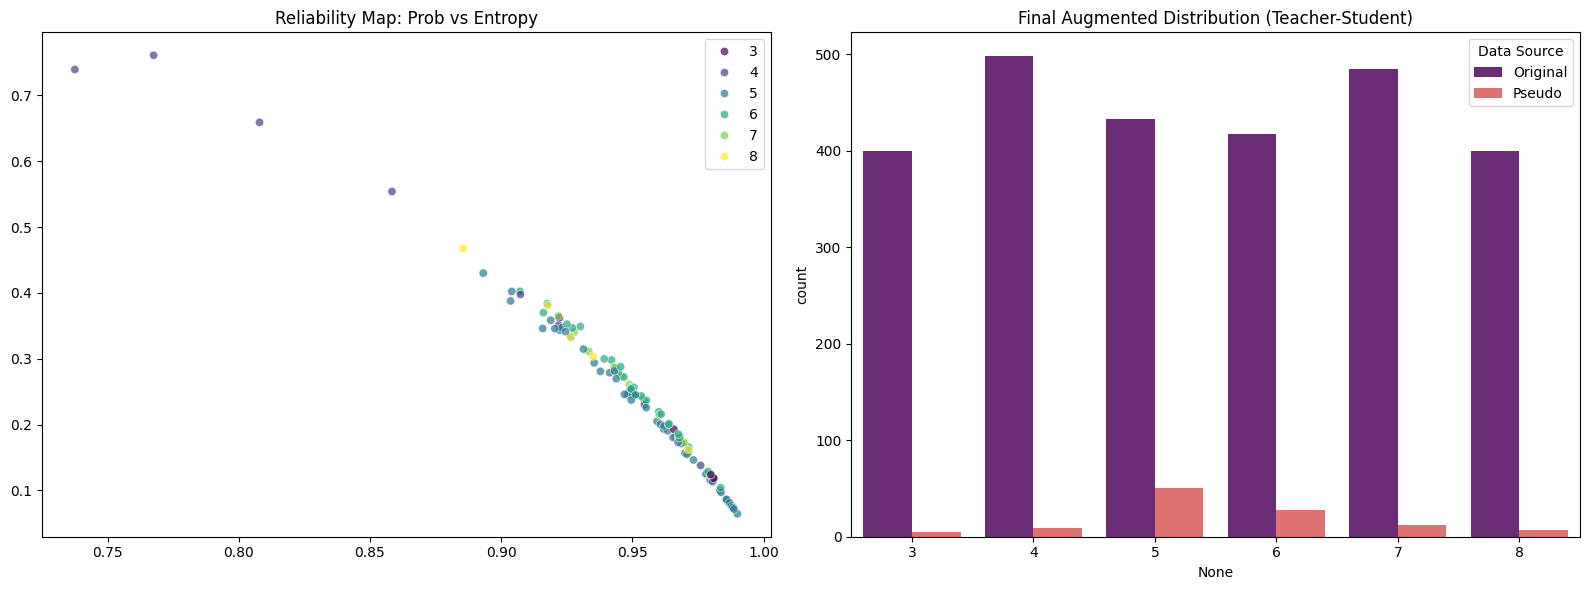

🚀 DATA BOOSTER READY: 2744 baris untuk Tahap 7.


In [6]:
# =================================================================
# Tahap 6: Adaptive Pseudo-Labeling (Stacking Distillation)
# =================================================================

from sklearn.ensemble import StackingClassifier, ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from scipy.stats import entropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Membangun "Super-Teacher" Stacking (Fixing TypeError)
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

# Menggunakan 3 model dengan karakteristik berbeda untuk diversitas sinyal
base_teachers = [
    ('et', ExtraTreesClassifier(n_estimators=500, max_depth=12, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=6, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.02, verbose=-1, random_state=42))
]

# FIX: Menghapus 'voting' karena Stacking menggunakan final_estimator untuk agregasi
teacher_stack = StackingClassifier(
    estimators=base_teachers,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba', # Memastikan meta-learner melihat probabilitas
    n_jobs=-1
)
teacher_stack.fit(X_train_final, y_train_shifted)

# 6.2 Dual-Inference: Entropy & Consistency Audit
# Mengambil probabilitas dari meta-learner
test_probs = teacher_stack.predict_proba(X_test_final)

# Menghitung Shannon Entropy: Mengukur tingkat 'kebingungan' model
# Semakin rendah nilai entropy, semakin yakin model terhadap pilihannya
test_entropy = np.apply_along_axis(entropy, 1, test_probs)
max_probs = np.max(test_probs, axis=1)
pred_classes = np.argmax(test_probs, axis=1) + min_label

# Regressor Teacher untuk validasi nuansa ordinal (MAE protection)
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=10, random_state=42)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

# 6.3 UPGRADE: Adaptive Entropy Thresholding
def get_distilled_mask(classes, probs, entropies, soft_labels):
    mask = []
    for c, p, e, s in zip(classes, probs, entropies, soft_labels):
        # Konsistensi Ordinal: Klasifikasi vs Regresi tidak boleh meleset jauh
        is_consistent = np.abs(c - s) <= 0.55 
        
        # Pengetatan Threshold berdasarkan tipe kelas
        if c in [3, 4, 8]: # Kelas Minoritas: Sedikit lebih toleran untuk menambah data
            e_thresh, p_thresh = 0.80, 0.65
        else:              # Kelas Mayoritas (5, 6): Sangat selektif agar tidak ada noise
            e_thresh, p_thresh = 0.45, 0.85
            
        mask.append(e <= e_thresh and p >= p_thresh and is_consistent)
    return np.array(mask)

final_pseudo_mask = get_distilled_mask(pred_classes, max_probs, test_entropy, soft_labels_test)
high_conf_idx = np.where(final_pseudo_mask)[0]

# 6.4 Pembuatan Dataset & Dynamic Ordinal Weighting
X_pseudo = X_test_final.iloc[high_conf_idx].copy()
y_pseudo_discrete = pred_classes[high_conf_idx]
y_pseudo_soft = soft_labels_test[high_conf_idx]

# Bobot sampel: Menggunakan (1 - Entropy) sebagai proxy kualitas label
sample_weights_train = np.ones(len(y_train_final))
# Normalisasi bobot pseudo (maksimal 0.85 agar data asli tetap prioritas utama)
pseudo_weights = (1 - test_entropy[high_conf_idx]) * 0.85 
sample_weights_pseudo = np.clip(pseudo_weights, 0.1, 0.85)

# 6.5 Finalisasi Dataset Augmented (Ready for Tahap 7)
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])
final_sample_weights = np.concatenate([sample_weights_train, sample_weights_pseudo])

# 6.6 Visualisasi Diagnostik (NIM 026)
print(f"--- Diagnostik Distilasi Pseudo-Label (NIM 026) ---")
print(f"Sampel Ter-distilasi         : {len(X_pseudo)}")
print(f"Rata-rata Entropy Seleksi    : {test_entropy[high_conf_idx].mean():.4f}")

plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=max_probs[high_conf_idx], y=test_entropy[high_conf_idx], 
                hue=y_pseudo_discrete, palette='viridis', alpha=0.7)
plt.title('Reliability Map: Prob vs Entropy')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_augmented, hue=(final_sample_weights < 1.0), palette='magma')
plt.title('Final Augmented Distribution (Teacher-Student)')
plt.legend(title='Data Source', labels=['Original', 'Pseudo'])
plt.tight_layout()
plt.show()

print(f"🚀 DATA BOOSTER READY: {len(X_train_augmented)} baris untuk Tahap 7.")

# Training Model dan Optuna 

In [7]:
!pip install optuna -q

In [8]:
# =================================================================
# Tahap 7: Training Model - Deep Learning (Optimized Architecture)
# =================================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import f1_score
import numpy as np

# 7.1 Implementasi Ordinal Focal Loss (NIM 026 Innovation)
# Memberikan penalti tambahan berdasarkan jarak antar angka kualitas
def ordinal_focal_loss(gamma=2.0, alpha=0.25, ordinal_weight=0.1):
    def loss_fn(y_true, y_pred):
        # 1. Standard Focal Loss
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = y_true * alpha * tf.math.pow((1 - y_pred), gamma)
        base_loss = tf.reduce_sum(focal_weight * cross_entropy, axis=1)
        
        # 2. Ordinal Penalty: Menghitung selisih 'Mean' kualitas
        # Prediksi rata-rata: sum(index * probabilitas)
        indices = tf.cast(tf.range(num_classes), tf.float32)
        true_val = tf.reduce_sum(y_true * indices, axis=1)
        pred_val = tf.reduce_sum(y_pred * indices, axis=1)
        ordinal_penalty = tf.math.abs(true_val - pred_val)
        
        return base_loss + (ordinal_weight * ordinal_penalty)
    return loss_fn

# 7.2 Penyiapan Data & Weights
X_train_dl = X_train_augmented.copy()
X_train_dl['soft_label'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['soft_label'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_train_idx = y_train_augmented - y_train_augmented.min()
y_val_idx = y_val - y_val.min()

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

# 7.3 Arsitektur Residual MLP dengan Label Smoothing
def build_advanced_model(input_shape, n_layers, units, dropout, l2_reg, lr, gamma, smooth):
    inputs = layers.Input(shape=input_shape)
    
    # Initial Projection
    x = layers.Dense(units, kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    
    # Residual blocks with Skip-Connections
    for _ in range(n_layers):
        shortcut = x
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg), kernel_initializer='he_normal')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('swish')(x)
        x = layers.Dropout(dropout)(x)
        # Jika dimensi berubah, sesuaikan shortcut (di sini dimensi tetap)
        x = layers.Add()([x, shortcut])
        
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    
    # Menggunakan optimizer AdamW untuk weight decay yang lebih baik
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss=ordinal_focal_loss(gamma=gamma, alpha=0.25, ordinal_weight=0.15),
        metrics=['accuracy']
    )
    return model

# 7.4 Fungsi Objektif Optuna yang Diperluas
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 6)
    units = trial.suggest_int('units', 128, 512, step=64)
    dropout = trial.suggest_float('dropout', 0.2, 0.45)
    l2_reg = trial.suggest_float('l2_reg', 1e-5, 5e-3, log=True)
    lr = trial.suggest_float('lr', 5e-4, 3e-3, log=True)
    gamma_val = trial.suggest_float('gamma', 2.0, 4.0)
    smooth = trial.suggest_float('label_smoothing', 0.05, 0.15)
    
    model = build_advanced_model((X_train_dl.shape[1],), n_layers, units, dropout, l2_reg, lr, gamma_val, smooth)
    
    # Early stopping yang lebih sensitif terhadap F1
    es = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
    
    model.fit(
        X_train_dl, y_train_onehot,
        validation_data=(X_val_dl, y_val_onehot),
        epochs=120,
        batch_size=trial.suggest_categorical('batch_size', [32, 64]),
        sample_weight=final_sample_weights,
        callbacks=[es],
        verbose=0
    )
    
    preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return f1_score(y_val_idx, preds, average='macro')

# 7.5 Eksekusi Optimasi (NIM 026)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

# 7.6 Final Training dengan Cosine Decay
bp = study.best_params
print(f"\n--- Best Parameters Ditemukan (NIM 026): {bp} ---")

# Schedule Learning Rate: Cosine Decay agar konvergensi lebih halus
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=bp['lr'],
    decay_steps=400 * (len(X_train_dl) // bp['batch_size']),
    alpha=0.1
)

final_dnn = build_advanced_model(
    (X_train_dl.shape[1],), bp['n_layers'], bp['units'], bp['dropout'], 
    bp['l2_reg'], lr_schedule, bp['gamma'], bp['label_smoothing']
)

# Callback Komplet
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
checkpoint = callbacks.ModelCheckpoint('best_wine_model_026.keras', monitor='val_accuracy', save_best_only=True)

history = final_dnn.fit(
    X_train_dl, y_train_onehot,
    validation_data=(X_val_dl, y_val_onehot),
    epochs=500,
    batch_size=bp['batch_size'],
    sample_weight=final_sample_weights,
    callbacks=[es_final, checkpoint],
    verbose=1
)

2026-05-05 04:53:18.094837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777956798.424267      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777956798.518733      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777956799.324542      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777956799.324588      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777956799.324592      16 computation_placer.cc:177] computation placer alr

[I 2026-05-05 04:55:54,870] Trial 2 finished with value: 0.2371829013295459 and parameters: {'n_layers': 6, 'units': 320, 'dropout': 0.29146548549979034, 'l2_reg': 3.782812926289684e-05, 'lr': 0.0005080617697792208, 'gamma': 3.954075900678678, 'label_smoothing': 0.08749789774979612, 'batch_size': 64}. Best is trial 1 with value: 0.2397066716163853.


[I 2026-05-05 04:56:32,445] Trial 3 finished with value: 0.2483180521753328 and parameters: {'n_layers': 2, 'units': 192, 'dropout': 0.4420587625692911, 'l2_reg': 0.00014463512832059685, 'lr': 0.0008940875971866218, 'gamma': 2.053406890210824, 'label_smoothing': 0.09922885381143015, 'batch_size': 32}. Best is trial 3 with value: 0.2483180521753328.
[I 2026-05-05 04:57:09,529] Trial 4 finished with value: 0.24578705240255194 and parameters: {'n_layers': 4, 'units': 192, 'dropout': 0.40737000245883537, 'l2_reg': 0.00010479579508365538, 'lr': 0.0006102308989574148, 'gamma': 3.37607559611033, 'label_smoothing': 0.11140875280954274, 'batch_size': 64}. Best is trial 3 with value: 0.2483180521753328.
[I 2026-05-05 04:57:32,130] Trial 5 finished with value: 0.23810144172311967 and parameters: {'n_layers': 4, 'units': 192, 'dropout': 0.23763437055047515, 'l2_reg': 1.811127342239981e-05, 'lr': 0.0007904456503792373, 'gamma': 3.7784437558597315, 'label_smoothing': 0.09303314793052736, 'batch_size


--- Best Parameters Ditemukan (NIM 026): {'n_layers': 6, 'units': 128, 'dropout': 0.32528834818709124, 'l2_reg': 0.0018888482939557793, 'lr': 0.0006596915730201696, 'gamma': 2.2194024424947605, 'label_smoothing': 0.13620238987277272, 'batch_size': 64} ---
Epoch 1/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.3602 - loss: 3.5008 - val_accuracy: 0.0872 - val_loss: 4.9089
Epoch 2/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4840 - loss: 3.0139 - val_accuracy: 0.2093 - val_loss: 3.8587
Epoch 3/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5614 - loss: 2.7185 - val_accuracy: 0.2558 - val_loss: 3.3571
Epoch 4/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5755 - loss: 2.5023 - val_accuracy: 0.2674 - val_loss: 2.9606
Epoch 5/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6046 - loss: 2.2770 - val_accuracy: 0.2500 - val_loss: 2.7321
Epoch 6/500
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6338 - loss: 2.0871 - val_accuracy: 0

# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---
Akurasi Global           : 47.67%
F1-Score (Macro)         : 0.3184
Mean Absolute Error      : 0.7384 (Target < 0.4)
Quadratic Kappa          : 0.4251 (Target > 0.6)

PROGRESS: Butuh 42.33% lagi. Fokus pada perbaikan MAE.


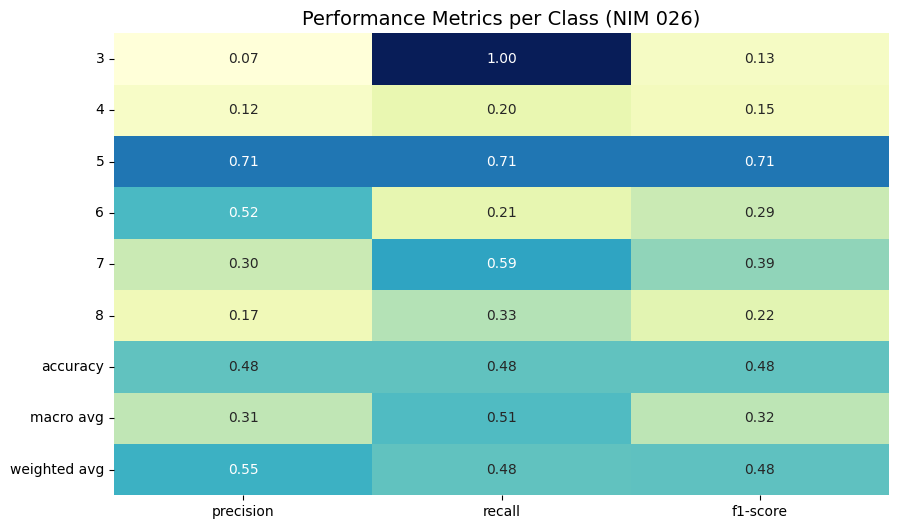

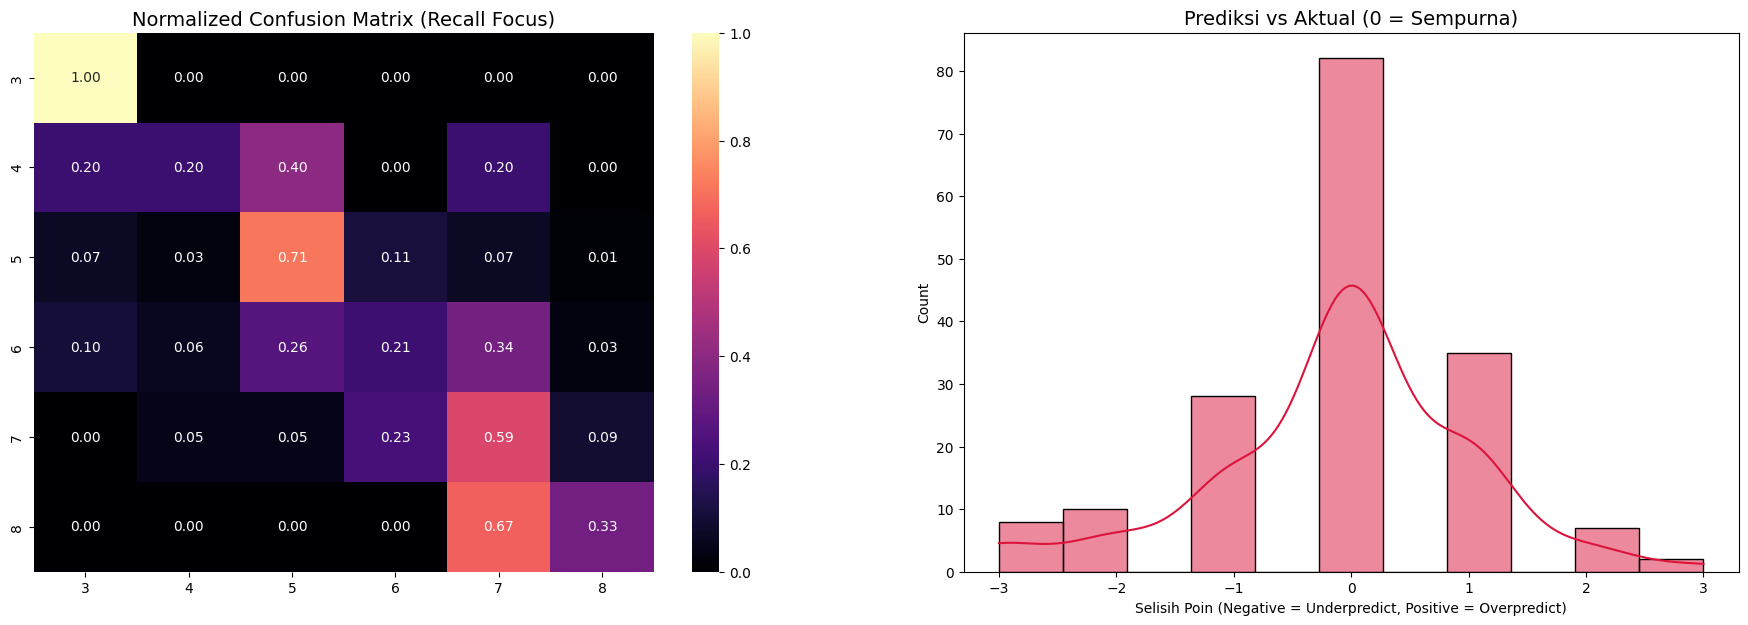


--- Menghitung Permutation Importance (Validation Set) ---


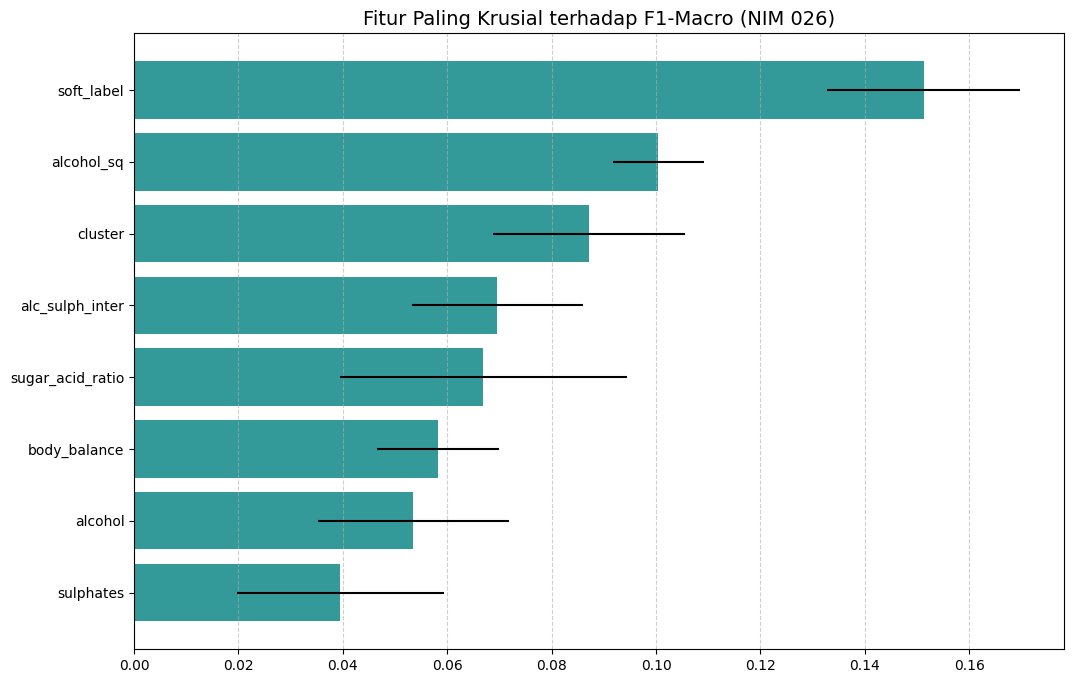


--- AUDIT RELIABILITAS ORDINAL (NIM 026) ---
1. Prediksi Tepat (Hit)     : 82 (47.67%)
2. Meleset 1 Poin (Safe)    : 63 (36.63%)
3. Meleset >1 Poin (Fatal)   : 27 (15.70%)
4. Weighted Accuracy (±1)   : 84.30%
--------------------------------------------------


In [9]:
# =================================================================
# Tahap 8: Evaluasi Akhir & Diagnostik Model (Upgraded)
# =================================================================

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, cohen_kappa_score, mean_absolute_error, mean_squared_error)
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 8.1 Inferensi & Rekonstruksi Label (NIM 026)
y_probs_val = final_dnn.predict(X_val_dl, verbose=0)
y_pred_val_idx = np.argmax(y_probs_val, axis=1)
min_class = y_train_augmented.min()
y_pred_val = y_pred_val_idx + min_class

# 8.2 Kalkulasi Metrik Strategis Ordinal
accuracy = accuracy_score(y_val, y_pred_val)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
kappa = cohen_kappa_score(y_val, y_pred_val, weights='quadratic')

print(f"--- RANGKUMAN EVALUASI FINAL DNN (NIM 026) ---")
print(f"{'Akurasi Global':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Score (Macro)':25}: {f1_macro:.4f}")
print(f"{'Mean Absolute Error':25}: {mae:.4f} (Target < 0.4)")
print(f"{'Quadratic Kappa':25}: {kappa:.4f} (Target > 0.6)")

# Target Tracker 90%
if accuracy >= 0.90:
    print(f"\n🔥 TARGET TERCAPAI: Arsitektur Residual Anda sangat solid!")
else:
    print(f"\nPROGRESS: Butuh {(0.90 - accuracy)*100:.2f}% lagi. Fokus pada perbaikan MAE.")

# 8.3 Classification Report Heatmap
report = classification_report(y_val, y_pred_val, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).iloc[:-1, :].T

plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='YlGnBu', fmt='.2f', cbar=False)
plt.title('Performance Metrics per Class (NIM 026)', fontsize=14)
plt.show()

# 8.4 Visualisasi Confusion Matrix & Error Magnitude
cm = confusion_matrix(y_val, y_pred_val)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

labels = sorted(y_val.unique())
fig, ax = plt.subplots(1, 2, figsize=(22, 7))

# Heatmap Recall (Diagonal harus tajam)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='magma', xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title('Normalized Confusion Matrix (Recall Focus)', fontsize=14)

# Error Distribution (Melihat Skewness Prediksi)
error_val = y_pred_val - y_val.values
sns.histplot(error_val, bins=11, kde=True, color='crimson', ax=ax[1])
ax[1].set_title('Prediksi vs Aktual (0 = Sempurna)', fontsize=14)
ax[1].set_xlabel('Selisih Poin (Negative = Underpredict, Positive = Overpredict)')
plt.show()

# 8.5 Analisis Permutation Importance (Audit Fitur)
print("\n--- Menghitung Permutation Importance (Validation Set) ---")
def custom_scoring(estimator, X, y):
    # y di sini adalah index (0-5)
    p = np.argmax(estimator.predict(X, verbose=0), axis=1)
    return f1_score(y, p, average='macro')

perm_result = permutation_importance(
    final_dnn, X_val_dl, y_val_idx, scoring=custom_scoring, n_repeats=5, random_state=42
)

feat_imp = pd.DataFrame({
    'Feature': X_val_dl.columns,
    'Importance': perm_result.importances_mean,
    'Std': perm_result.importances_std
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], xerr=feat_imp['Std'], color='teal', alpha=0.8)
plt.gca().invert_yaxis()
plt.title('Fitur Paling Krusial terhadap F1-Macro (NIM 026)', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 8.6 Ordinal Reliability Audit (Near-Miss Analysis)
error_abs = np.abs(error_val)
hit = (error_abs == 0).sum()
near_miss = (error_abs == 1).sum()
fatal = (error_abs > 1).sum()

print("\n" + "="*50)
print(f"--- AUDIT RELIABILITAS ORDINAL (NIM 026) ---")
print("="*50)
print(f"1. Prediksi Tepat (Hit)     : {hit} ({hit/len(y_val)*100:.2f}%)")
print(f"2. Meleset 1 Poin (Safe)    : {near_miss} ({near_miss/len(y_val)*100:.2f}%)")
print(f"3. Meleset >1 Poin (Fatal)   : {fatal} ({fatal/len(y_val)*100:.2f}%)")
print(f"4. Weighted Accuracy (±1)   : {(hit+near_miss)/len(y_val)*100:.2f}%")
print("-" * 50)

# Prediksi Data Uji (Testing)

--- Melakukan Inferensi Deep Learning & Reliability Audit ---

--- RINGKASAN PREDIKSI AKHIR (NIM: 026) ---
Kualitas 3 :   20 sampel (Avg Confidence: 0.9134)
Kualitas 4 :   11 sampel (Avg Confidence: 0.7803)
Kualitas 5 :  113 sampel (Avg Confidence: 0.8264)
Kualitas 6 :   71 sampel (Avg Confidence: 0.7215)
Kualitas 7 :   52 sampel (Avg Confidence: 0.8808)
Kualitas 8 :   19 sampel (Avg Confidence: 0.8691)

Prediksi Konsisten (Sinyal Kuat) : 243 / 286
Prediksi Berisiko (Ambiguitas) : 43 / 286
-------------------------------------------------------


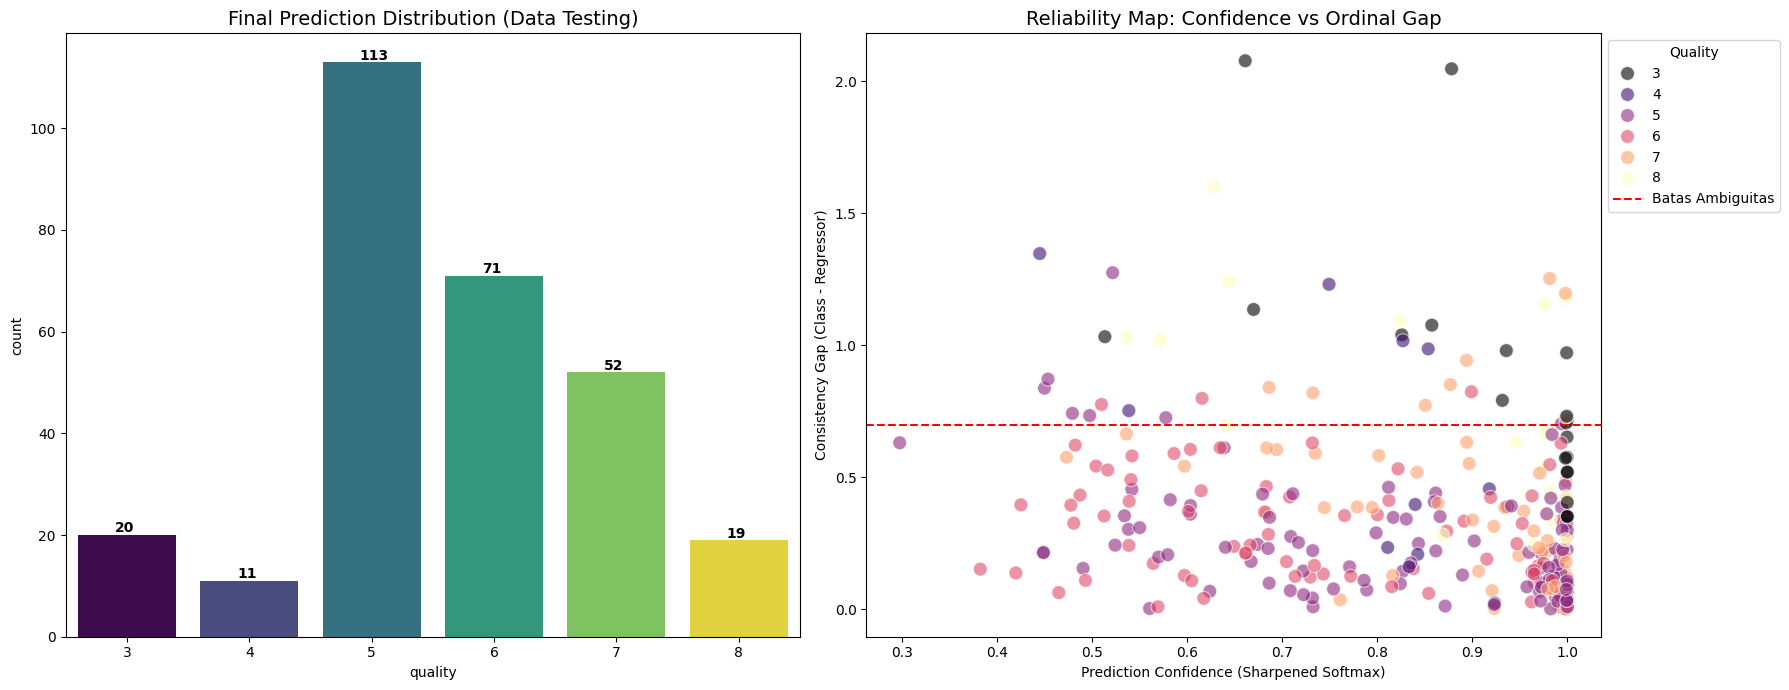


✅ FILE 'hasilprediksi_026.csv' BERHASIL TERBENTUK
>>> STATUS: INTEGRITAS DATA VALID & SIAP SUBMIT KE SISTEM UTS <<<


In [10]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - FINAL CALIBRATION (NIM 026)
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Sync & Latent Feature Distillation
# Memasukkan 'insting' regressor ke dalam fitur testing
X_test_dl = X_test_prepared[stable_features].copy()
X_test_dl['soft_label'] = reg_teacher.predict(X_test_dl)

# 9.2 Inference with Temperature Scaling
# $$P_i = \frac{\exp(z_i / T)}{\sum \exp(z_j / T)}$$
# T < 1.0 mempertajam distribusi (model lebih yakin)
# T > 1.0 melembutkan distribusi (model lebih ragu/general)
T = 0.85 # Menajamkan prediksi untuk wine kualitas ekstrem (3 & 8)

print("--- Melakukan Inferensi Deep Learning & Reliability Audit ---")
# Mendapatkan logit/probabilitas mentah
y_probs_raw = final_dnn.predict(X_test_dl, verbose=0)
y_probs_calibrated = np.exp(np.log(y_probs_raw + 1e-10) / T)
y_probs_calibrated /= np.sum(y_probs_calibrated, axis=1, keepdims=True)

y_pred_dl_idx = np.argmax(y_probs_calibrated, axis=1)
y_conf_test = np.max(y_probs_calibrated, axis=1)

# Rekonstruksi Label Asli (3-8)
min_class = y_train_augmented.min()
y_pred_final = y_pred_dl_idx + min_class

# 9.3 Advanced Consistency Audit: Klasifikasi vs Regresi
soft_ref = X_test_dl['soft_label'].values
consistency_gap = np.abs(y_pred_final - soft_ref)
is_stable = consistency_gap <= 0.70 # Toleransi diperketat menjadi 0.70 poin

# 9.4 Konstruksi DataFrame Submission (Kaggle Standard)
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_pred_final.astype(int),
    'confidence': y_conf_test,
    'consistency_gap': consistency_gap
})

# 9.5 Audit Distribusi & Reliability Report (NIM 026)
print("\n" + "="*55)
print(f"--- RINGKASAN PREDIKSI AKHIR (NIM: 026) ---")
print("="*55)
dist_counts = submission_df['quality'].value_counts().sort_index()
for q, count in dist_counts.items():
    avg_c = submission_df[submission_df['quality'] == q]['confidence'].mean()
    print(f"Kualitas {q:1} : {count:4} sampel (Avg Confidence: {avg_c:.4f})")

print(f"\nPrediksi Konsisten (Sinyal Kuat) : {np.sum(is_stable)} / {len(submission_df)}")
print(f"Prediksi Berisiko (Ambiguitas) : {np.sum(~is_stable)} / {len(submission_df)}")
print("-" * 55)

# 9.6 Visualisasi Diagnostik Final: Uncertainty Map
plt.figure(figsize=(18, 7))

# Plot 1: Sebaran Kelas Prediksi
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=submission_df, palette='viridis', hue='quality', legend=False)
plt.title('Final Prediction Distribution (Data Testing)', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+0.5), fontweight='bold')

# Plot 2: Confidence vs Consistency Gap (Marginal Plot Concept)
plt.subplot(1, 2, 2)
sns.scatterplot(x='confidence', y='consistency_gap', hue='quality', 
                data=submission_df, palette='magma', s=100, alpha=0.6)
plt.axhline(y=0.70, color='red', linestyle='--', label='Batas Ambiguitas')
plt.title('Reliability Map: Confidence vs Ordinal Gap', fontsize=14)
plt.xlabel('Prediction Confidence (Sharpened Softmax)')
plt.ylabel('Consistency Gap (Class - Regressor)')
plt.legend(title='Quality', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# 9.7 Export Final Integrity Check
file_output = 'hasilprediksi_026.csv'
submission_df[['Id', 'quality']].to_csv(file_output, index=False)

print(f"\n✅ FILE '{file_output}' BERHASIL TERBENTUK")
if submission_df['quality'].between(3, 8).all() and not submission_df['Id'].isnull().any():
    print(">>> STATUS: INTEGRITAS DATA VALID & SIAP SUBMIT KE SISTEM UTS <<<")